# 🦅 Bird Species Observation Analysis
### Data Cleaning, Preprocessing & Exploratory Data Analysis (EDA)

**Project:** Analyze the distribution and diversity of bird species across two ecosystems — **Forest** and **Grassland** — to understand how environmental factors, location, and observation conditions influence bird populations and behavior.

**Structure of this notebook:**
1. Setup & Data Loading
2. Data Cleaning & Preprocessing
3. Temporal Analysis (seasonal trends, time-of-day activity)
4. Spatial Analysis (admin units, plots, habitat hotspots)
5. Species Analysis (diversity, activity patterns, sex ratio)
6. Environmental Conditions (temperature, humidity, sky, wind, disturbance)
7. Distance & Behavior (proximity, flyovers)
8. Observer Trends
9. Conservation Insights (PIF Watchlist, Regional Stewardship)
10. Key Findings & Recommendations
11. Export cleaned data (CSV + SQLite) for the Streamlit dashboard

> This notebook reuses the same cleaning logic as `app.py` (imported directly) so the notebook, the dashboard, and the database always stay in sync. If you only want the pipeline output, just run `python app.py` from the terminal instead.


## 1. Setup & Data Loading

In [1]:
import sys
sys.path.append('.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

import app  # our ETL module (app.py) — reuse its loading/cleaning functions

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', 50)

print('Libraries loaded.')


Libraries loaded.


In [2]:
# If you don't have real data yet, generate a synthetic sample dataset that matches
# the project's schema (Forest & Grassland workbooks, multi-sheet by admin unit).
import os
if not app.RAW_FOREST_PATH.exists() or not app.RAW_GRASSLAND_PATH.exists():
    import generate_sample_data  # this will build the sample workbooks in data/
    print('Sample data generated.')
else:
    print('Raw data files already present.')


Raw data files already present.


In [3]:
raw_df = app.load_raw_data()
print(f"Raw rows: {len(raw_df):,}")
print(f"Admin units: {sorted(raw_df['Admin_Unit_Code'].unique())}")
print(f"Habitat types: {raw_df['Location_Type'].unique()}")
raw_df.head()


Raw rows: 5,990
Admin units: ['ANTI', 'CATO', 'CHOH', 'GWMP', 'HAFE', 'MANA', 'MONO', 'NACE', 'PRWI', 'ROCR', 'WOTR']
Habitat types: <ArrowStringArray>
['Forest', 'Grassland']
Length: 2, dtype: str


,Admin_Unit_Code,Sub_Unit_Code,Site_Name,Plot_Name,Location_Type,Year,Date,Start_Time,End_Time,Observer,Visit,Interval_Length,ID_Method,Distance,Flyover_Observed,Sex,Common_Name,Scientific_Name,AcceptedTSN,NPSTaxonCode,AOU_Code,PIF_Watchlist_Status,Regional_Stewardship_Status,Temperature,Humidity,Sky,Wind,Disturbance,Initial_Three_Min_Cnt
0,ANTI,ANTI-3,ANTI Site 2,ANTI-P04,Forest,2022,2022-05-24,05:40,05:48,M. Okafor,1,7.5-10 min,Non-vocal,50 - 100 Meters,False,Female,Northern Cardinal,Cardinalis cardinalis,179263,NPS-NOCA,NOCA,False,False,57.6,61.0,Light Rain,Light breeze (4-7 mph),Slight effect on count,1
1,ANTI,ANTI-3,ANTI Site 2,ANTI-P04,Forest,2022,2022-04-03,07:50,07:58,S. Patel,1,5-7.5 min,Singing,> 100 Meters,False,Undetermined,Song Sparrow,Melospiza melodia,179231,NPS-SOSP,SOSP,False,False,67.6,57.0,Light Rain,Light breeze (4-7 mph),Slight effect on count,4
2,ANTI,ANTI-1,ANTI Site 3,ANTI-P05,Forest,2024,2024-05-09,09:15,09:23,R. Fischer,1,2.5-5 min,Non-vocal,> 100 Meters,False,Female,Eastern Meadowlark,Sturnella magna,179545,NPS-EAME,EAME,True,True,77.0,58.0,Light Rain,Gentle breeze (8-12 mph),Slight effect on count,3
3,ANTI,ANTI-1,ANTI Site 1,ANTI-P01,Forest,2024,2024-05-07,08:40,08:48,S. Patel,3,5-7.5 min,Calling,> 100 Meters,False,Female,Tufted Titmouse,Baeolophus bicolor,178420,NPS-TUTI,TUTI,False,False,68.5,64.0,Clear,Gentle breeze (8-12 mph),Slight effect on count,5
4,ANTI,ANTI-3,ANTI Site 1,ANTI-P06,Forest,2023,2023-06-15,05:30,05:41,M. Okafor,3,2.5-5 min,Calling,50 - 100 Meters,False,Male,Red-winged Blackbird,Agelaius phoeniceus,179466,NPS-RWBL,RWBL,False,False,65.2,53.0,Cloudy/Overcast,Light breeze (4-7 mph),Moderate effect on count,3


## 2. Data Cleaning & Preprocessing

Cleaning steps performed (see `app.py::clean_data()` for the full implementation, reused here so notebook and dashboard never drift apart):

- Standardize column names and text fields (trim whitespace, consistent casing)
- Parse `Date`, `Start_Time`, `End_Time` into proper datetime/time types
- Normalize boolean-like columns (`Flyover_Observed`, `PIF_Watchlist_Status`, `Regional_Stewardship_Status`) stored inconsistently as `TRUE`/`FALSE`/`1`/`0`/text
- Convert `Temperature`, `Humidity`, `Initial_Three_Min_Cnt` to numeric; impute missing values using the species-level median (falls back to global median)
- Drop exact duplicate rows and rows missing species identification (the one field every analysis depends on)
- Map `Admin_Unit_Code` to full site names
- Engineer new analysis-ready features: `Month`, `Month_Name`, `Season`, `Observation_Time_Bin`, `Distance_Approx_m` (numeric midpoint of the distance bucket), `Watchlist_Flag`


In [4]:
clean_df = app.clean_data(raw_df)
print(f"Cleaned rows: {len(clean_df):,}")
clean_df.info()


Cleaning summary: removed 66 duplicate rows, 0 rows missing species ID. Final row count: 5,924
Cleaned rows: 5,924
<class 'pandas.DataFrame'>
RangeIndex: 5924 entries, 0 to 5923
Data columns (total 36 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Admin_Unit_Code              5924 non-null   str           
 1   Sub_Unit_Code                5924 non-null   str           
 2   Site_Name                    5924 non-null   str           
 3   Plot_Name                    5924 non-null   str           
 4   Location_Type                5924 non-null   str           
 5   Year                         5924 non-null   Int64         
 6   Date                         5924 non-null   datetime64[us]
 7   Start_Time                   5924 non-null   object        
 8   End_Time                     5924 non-null   object        
 9   Observer                     5924 non-null   str           
 10  Visi

In [5]:
# Missing-value check after cleaning
missing = clean_df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing.to_frame('missing_count')


,missing_count
Distance,117
Distance_Approx_m,117


In [6]:
clean_df.describe(include='all').T.head(20)

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Admin_Unit_Code,5924,11,CATO,659,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sub_Unit_Code,5924,33,CATO-1,237,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Site_Name,5924,39,CHOH Site 2,325,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Plot_Name,5924,78,CHOH-P06,124,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location_Type,5924,2,Forest,3256,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,5924.0,<NA>,<NA>,<NA>,2022.493248,2021.0,2021.0,2022.0,2024.0,2024.0,1.121124
Date,5924,NaN,NaN,NaN,2022-11-26 05:50:45.779878,2021-04-01 00:00:00,2021-07-26 00:00:00,2022-07-26 00:00:00,2024-04-01 00:00:00,2024-07-27 00:00:00,NaN
Start_Time,5924,40,06:00:00,182,NaN,NaN,NaN,NaN,NaN,NaN,NaN
End_Time,5924,160,07:41:00,58,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Observer,5924,8,S. Patel,781,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Temporal Analysis — Seasonal Trends & Time-of-Day Activity

In [7]:
yearly = clean_df.groupby(['Year', 'Location_Type']).size().reset_index(name='Observations')
fig = px.line(yearly, x='Year', y='Observations', color='Location_Type', markers=True,
              title='Observations by Year and Habitat Type')
fig.show()


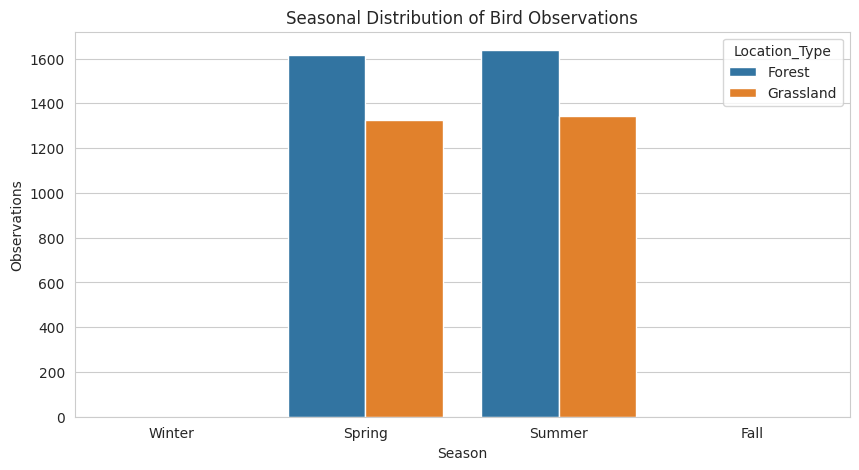

In [8]:
season_order = ['Winter', 'Spring', 'Summer', 'Fall']
seasonal = clean_df.groupby(['Season', 'Location_Type']).size().reset_index(name='Observations')
seasonal['Season'] = pd.Categorical(seasonal['Season'], categories=season_order, ordered=True)
seasonal = seasonal.sort_values('Season')

fig, ax = plt.subplots()
sns.barplot(data=seasonal, x='Season', y='Observations', hue='Location_Type', ax=ax)
ax.set_title('Seasonal Distribution of Bird Observations')
plt.show()


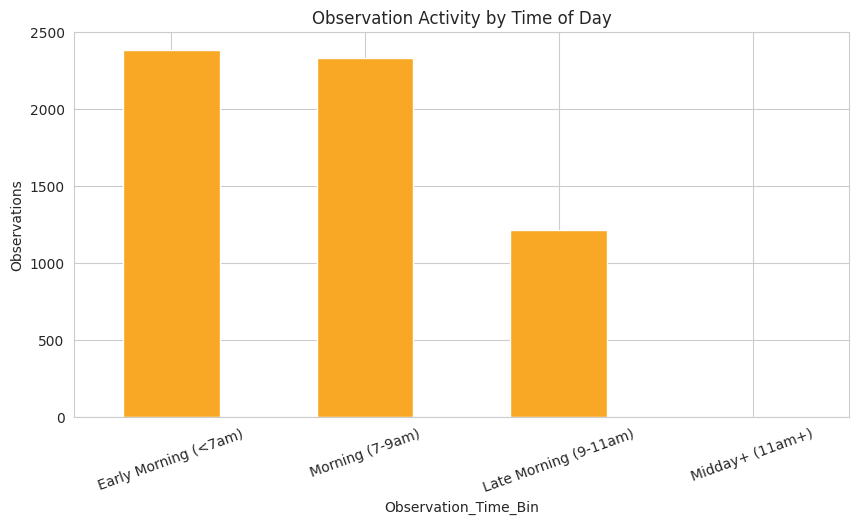

Insight: peak activity window -> Early Morning (<7am)


In [9]:
time_bin_order = ['Early Morning (<7am)', 'Morning (7-9am)', 'Late Morning (9-11am)', 'Midday+ (11am+)']
time_counts = clean_df['Observation_Time_Bin'].value_counts().reindex(time_bin_order)

fig, ax = plt.subplots()
time_counts.plot(kind='bar', color='#F9A825', ax=ax)
ax.set_title('Observation Activity by Time of Day')
ax.set_ylabel('Observations')
plt.xticks(rotation=20)
plt.show()

print("Insight: peak activity window ->", time_counts.idxmax())


## 4. Spatial Analysis — Biodiversity Hotspots

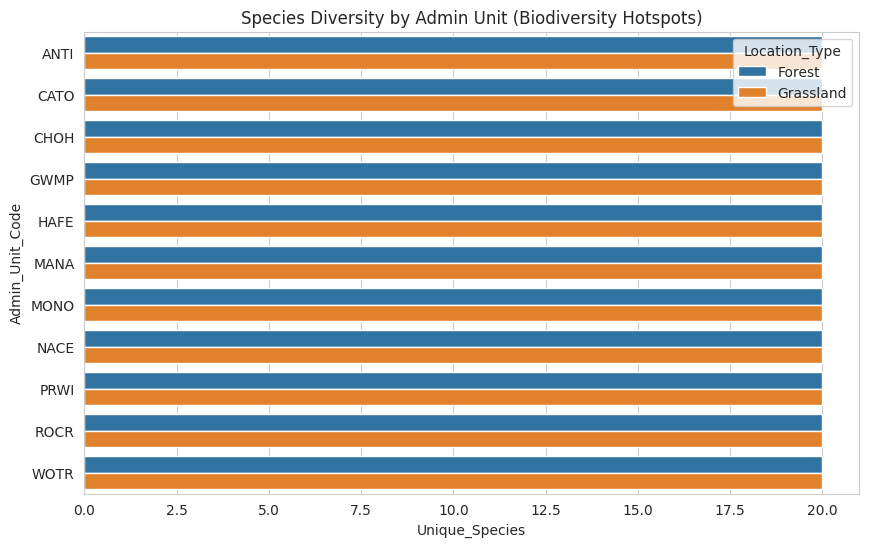

,Admin_Unit_Code,Location_Type,Unique_Species
0,ANTI,Forest,20
1,ANTI,Grassland,20
2,CATO,Forest,20
3,CATO,Grassland,20
4,CHOH,Forest,20


In [10]:
div_by_unit = clean_df.groupby(['Admin_Unit_Code', 'Location_Type'])['Common_Name'].nunique().reset_index(name='Unique_Species')
div_by_unit = div_by_unit.sort_values('Unique_Species', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=div_by_unit, y='Admin_Unit_Code', x='Unique_Species', hue='Location_Type', ax=ax)
ax.set_title('Species Diversity by Admin Unit (Biodiversity Hotspots)')
plt.show()

div_by_unit.head(5)


In [11]:
plot_div = clean_df.groupby('Plot_Name')['Common_Name'].nunique().sort_values(ascending=False).head(10)
plot_div.to_frame('Unique_Species')


,Unique_Species
Plot_Name,
ANTI-P02,20
ANTI-P04,20
ANTI-P06,20
CATO-P04,20
CATO-P01,20
CATO-P02,20
CATO-P05,20
CATO-P06,20
CATO-P03,20


## 5. Species Analysis — Diversity, Activity Patterns & Sex Ratio

Total unique species observed: 20


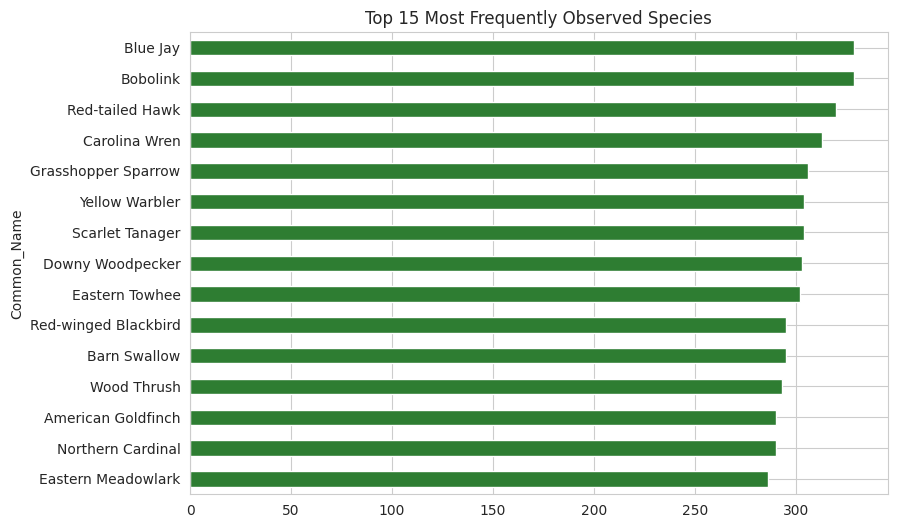

In [12]:
print(f"Total unique species observed: {clean_df['Common_Name'].nunique()}")

top_species = clean_df['Common_Name'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(9, 6))
top_species.sort_values().plot(kind='barh', color='#2E7D32', ax=ax)
ax.set_title('Top 15 Most Frequently Observed Species')
plt.show()


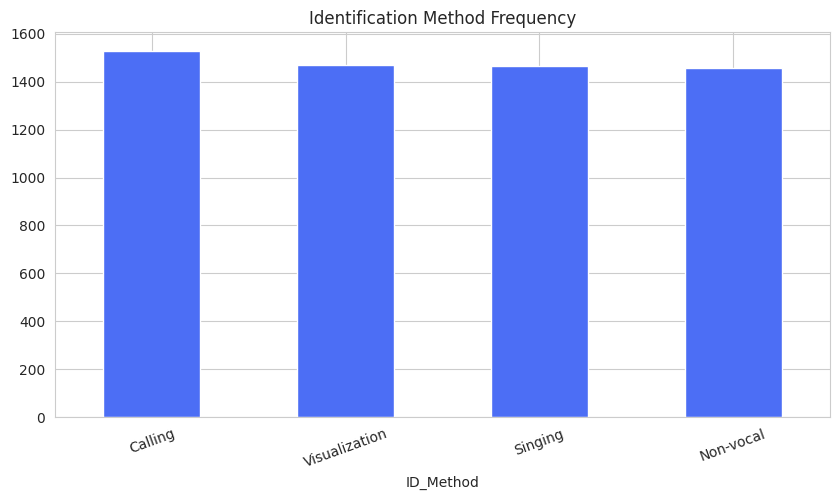

Most common ID method: Calling


In [13]:
method_counts = clean_df['ID_Method'].value_counts()
fig, ax = plt.subplots()
method_counts.plot(kind='bar', color='#4C6EF5', ax=ax)
ax.set_title('Identification Method Frequency')
plt.xticks(rotation=20)
plt.show()

print("Most common ID method:", method_counts.idxmax())


In [14]:
sex_counts = clean_df['Sex'].value_counts(normalize=True) * 100
sex_counts.round(1).to_frame('% of observations')


,% of observations
Sex,
Undetermined,35.3
Female,33.1
Male,31.6


## 6. Environmental Conditions — Weather Correlation

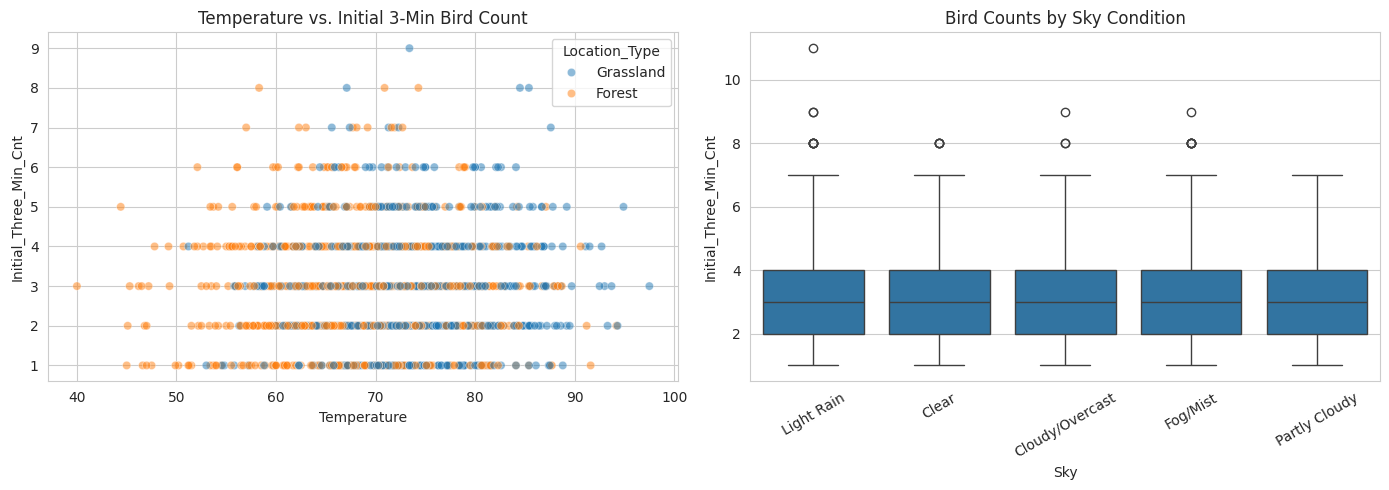

,Temperature,Humidity,Initial_Three_Min_Cnt,Distance_Approx_m
Temperature,1.000000,-0.009501,0.001656,-0.001426
Humidity,-0.009501,1.000000,-0.007580,0.018705
Initial_Three_Min_Cnt,0.001656,-0.007580,1.000000,0.001560
Distance_Approx_m,-0.001426,0.018705,0.001560,1.000000


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=clean_df.sample(min(1500, len(clean_df)), random_state=1),
                 x='Temperature', y='Initial_Three_Min_Cnt', hue='Location_Type', alpha=0.5, ax=axes[0])
axes[0].set_title('Temperature vs. Initial 3-Min Bird Count')

sns.boxplot(data=clean_df, x='Sky', y='Initial_Three_Min_Cnt', ax=axes[1])
axes[1].set_title('Bird Counts by Sky Condition')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

corr = clean_df[['Temperature', 'Humidity', 'Initial_Three_Min_Cnt', 'Distance_Approx_m']].corr()
corr


In [16]:
disturbance_effect = clean_df.groupby('Disturbance')['Initial_Three_Min_Cnt'].mean().sort_values(ascending=False)
disturbance_effect.to_frame('Avg. Bird Count')


,Avg. Bird Count
Disturbance,
Slight effect on count,3.028615
No effect on count,3.016327
Moderate effect on count,2.981565


## 7. Distance & Behavior

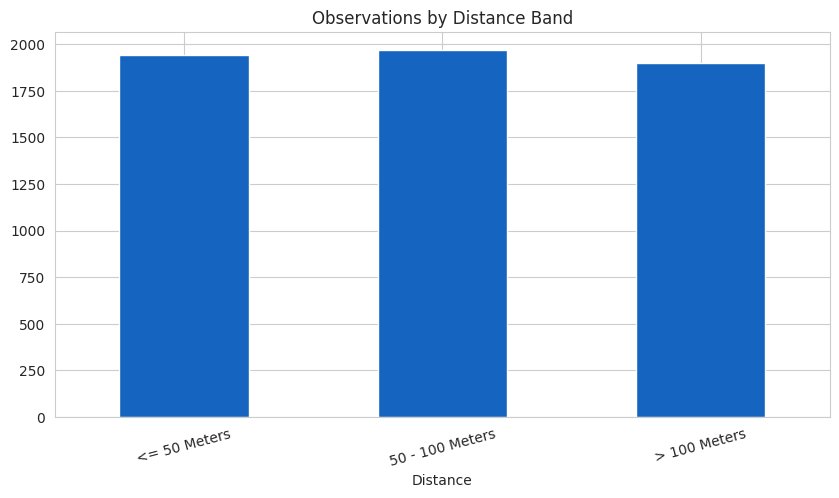

Flyover observation rate: 16.8%


In [17]:
dist_order = ['<= 50 Meters', '50 - 100 Meters', '> 100 Meters']
dist_counts = clean_df['Distance'].value_counts().reindex(dist_order)

fig, ax = plt.subplots()
dist_counts.plot(kind='bar', color='#1565C0', ax=ax)
ax.set_title('Observations by Distance Band')
plt.xticks(rotation=15)
plt.show()

flyover_rate = clean_df['Flyover_Observed'].mean() * 100
print(f"Flyover observation rate: {flyover_rate:.1f}%")


In [18]:
dist_by_species = (clean_df.groupby('Common_Name')['Distance_Approx_m']
                    .agg(['mean', 'count']).query('count >= 5')
                    .sort_values('mean'))
print("Species typically observed CLOSEST:")
display(dist_by_species.head(5))
print("Species typically observed FARTHEST:")
display(dist_by_species.tail(5))


Species typically observed CLOSEST:


,mean,count
Common_Name,,
Indigo Bunting,70.669291,254
Tufted Titmouse,71.000000,275
Eastern Towhee,72.448980,294
Yellow Warbler,73.316498,297
American Robin,73.351648,273


Species typically observed FARTHEST:


,mean,count
Common_Name,,
Song Sparrow,76.351351,259
Red-winged Blackbird,76.718213,291
Eastern Meadowlark,76.805054,277
American Goldfinch,76.923077,286
Barn Swallow,77.413793,290


## 8. Observer Trends

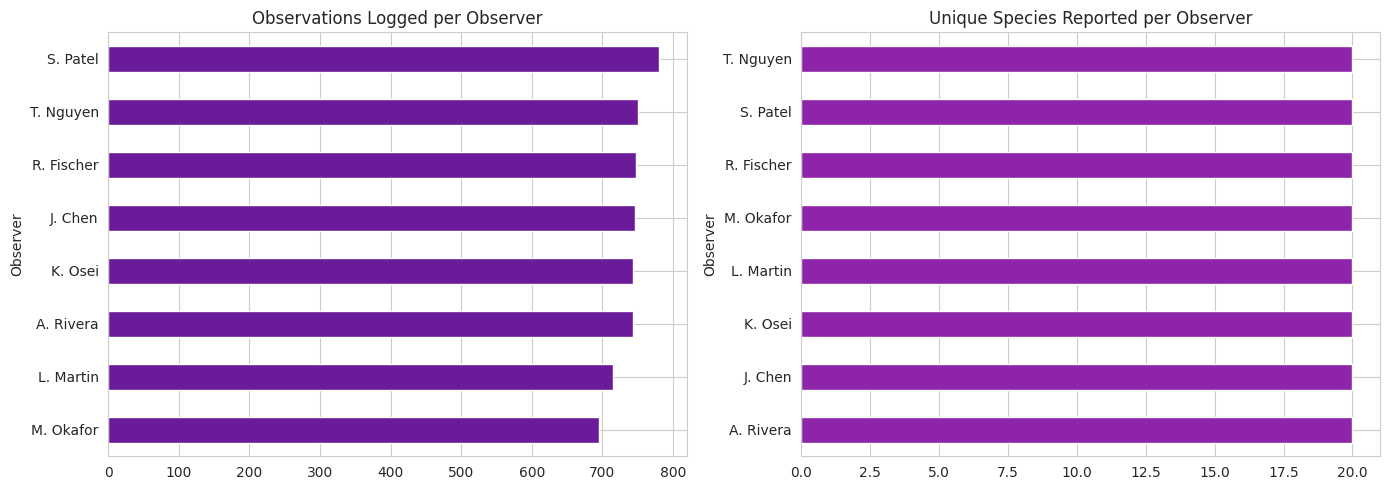

In [19]:
obs_counts = clean_df['Observer'].value_counts()
obs_div = clean_df.groupby('Observer')['Common_Name'].nunique().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
obs_counts.sort_values().plot(kind='barh', ax=axes[0], color='#6A1B9A')
axes[0].set_title('Observations Logged per Observer')

obs_div.sort_values().plot(kind='barh', ax=axes[1], color='#8E24AA')
axes[1].set_title('Unique Species Reported per Observer')
plt.tight_layout()
plt.show()


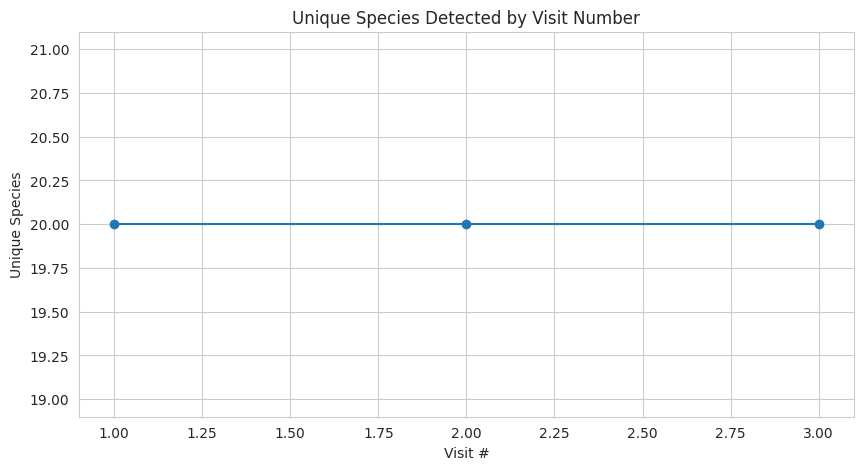

In [20]:
visit_div = clean_df.groupby('Visit')['Common_Name'].nunique()
fig, ax = plt.subplots()
visit_div.plot(marker='o', ax=ax)
ax.set_title('Unique Species Detected by Visit Number')
ax.set_xlabel('Visit #')
ax.set_ylabel('Unique Species')
plt.show()


## 9. Conservation Insights — PIF Watchlist & Regional Stewardship

Species on the PIF Watchlist: 7
Species with Regional Stewardship status: 8


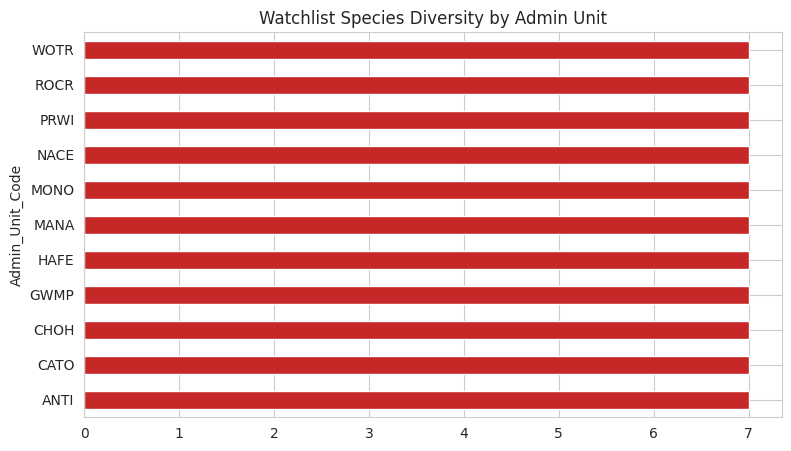

In [21]:
watch_species = clean_df[clean_df['PIF_Watchlist_Status']]['Common_Name'].nunique()
steward_species = clean_df[clean_df['Regional_Stewardship_Status']]['Common_Name'].nunique()
print(f"Species on the PIF Watchlist: {watch_species}")
print(f"Species with Regional Stewardship status: {steward_species}")

watch_by_unit = (clean_df[clean_df['PIF_Watchlist_Status']]
                  .groupby('Admin_Unit_Code')['Common_Name'].nunique()
                  .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(9, 5))
watch_by_unit.sort_values().plot(kind='barh', color='#C62828', ax=ax)
ax.set_title('Watchlist Species Diversity by Admin Unit')
plt.show()


In [22]:
priority_species = (clean_df[clean_df['PIF_Watchlist_Status'] | clean_df['Regional_Stewardship_Status']]
    .groupby(['Common_Name', 'Scientific_Name'])
    .agg(Observations=('Common_Name', 'size'),
         Admin_Units=('Admin_Unit_Code', 'nunique'),
         PIF_Watchlist=('PIF_Watchlist_Status', 'max'),
         Regional_Stewardship=('Regional_Stewardship_Status', 'max'))
    .reset_index()
    .sort_values('Observations', ascending=False))
priority_species


,Common_Name,Scientific_Name,Observations,Admin_Units,PIF_Watchlist,Regional_Stewardship
0,Bobolink,Dolichonyx oryzivorus,329,11,True,True
1,Carolina Wren,Thryothorus ludovicianus,313,11,False,True
5,Grasshopper Sparrow,Ammodramus savannarum,306,11,True,True
7,Scarlet Tanager,Piranga olivacea,304,11,True,False
3,Eastern Towhee,Pipilo erythrophthalmus,302,11,True,True
8,Wood Thrush,Hylocichla mustelina,293,11,True,True
2,Eastern Meadowlark,Sturnella magna,286,11,True,True
4,Field Sparrow,Spizella pusilla,279,11,True,True
6,Indigo Bunting,Passerina cyanea,257,11,False,True


## 10. Key Findings & Recommendations

*(Findings below are illustrative — they will reflect the synthetic sample data until the real dataset is loaded. Re-run this notebook after swapping in the real workbooks to get real conclusions.)*

**Temporal:**
- Note the peak season / peak time-of-day identified above — this is when survey effort and re-engagement messaging (e.g., volunteer scheduling) are most valuable.

**Spatial:**
- The admin units and plots with the highest unique-species counts are the strongest candidates for eco-tourism development and habitat-protection prioritization.

**Species & Environment:**
- Compare the most common ID method and how counts move with temperature/sky condition — this informs the best survey conditions for future monitoring.

**Conservation:**
- The species table above flags every bird on the PIF Watchlist or with Regional Stewardship status — these should anchor any conservation policy brief, along with the admin units where they concentrate.

**Recommended next steps:**
1. Validate findings once real observation data replaces the synthetic sample.
2. Feed `data/bird_data_cleaned.csv` / `db/bird_observations.db` into the Streamlit dashboard (`dashboard.py`) for stakeholder-friendly, interactive exploration.
3. Consider a follow-up multi-year trend model if more years of data become available (only 4 synthetic survey years are simulated here).


## 11. Export Cleaned Data (CSV + SQLite) for the Dashboard

In [23]:
app.save_outputs(clean_df)
print("Done — data/bird_data_cleaned.csv and db/bird_observations.db are up to date.")
print("Launch the dashboard with:  streamlit run dashboard.py")


Saved cleaned CSV -> /home/claude/bird_project/data/bird_data_cleaned.csv (5,924 rows)


Saved SQLite DB -> /home/claude/bird_project/db/bird_observations.db (table: observations)
Done — data/bird_data_cleaned.csv and db/bird_observations.db are up to date.
Launch the dashboard with:  streamlit run dashboard.py
